Loading data from C:\Users\NITRO V\Downloads\DAV exps\Salary_dataset.csv...
--- Model Training Complete ---
Slope (m): 9449.9623
Intercept (b): 24848.2040
R-squared Score: 0.9570


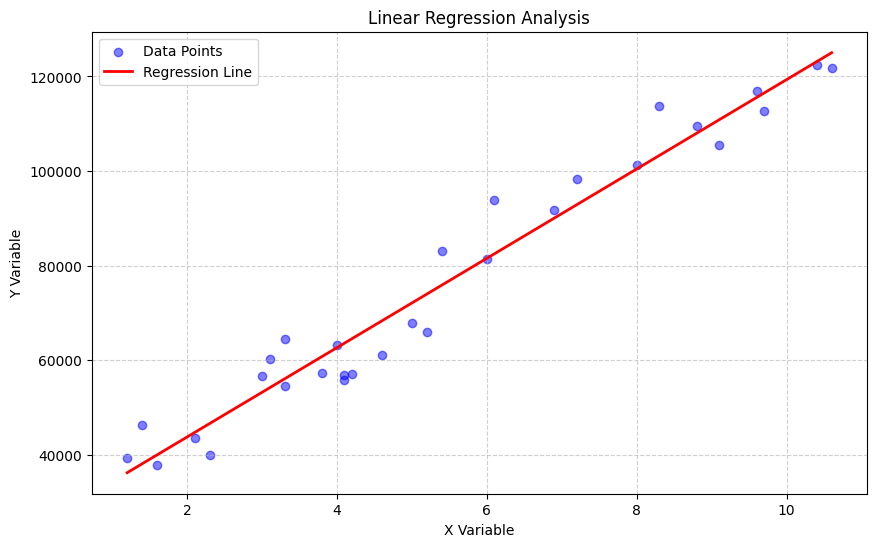

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

class SimpleLinearRegression:
    """
    A class to perform Simple Linear Regression (y = mx + b)
    using the Ordinary Least Squares (OLS) method.
    """
    
    def __init__(self):
        self.slope = None
        self.intercept = None

    def fit(self, x, y):
        """
        Calculates the slope (m) and intercept (b) using the OLS formulas.
        """
        x = np.array(x).flatten()
        y = np.array(y).flatten()
        
        # Remove NaNs if any exist in the provided data
        mask = ~np.isnan(x) & ~np.isnan(y)
        x, y = x[mask], y[mask]
        
        x_mean = np.mean(x)
        y_mean = np.mean(y)
        
        numerator = np.sum((x - x_mean) * (y - y_mean))
        denominator = np.sum((x - x_mean)**2)
        
        self.slope = numerator / denominator
        self.intercept = y_mean - (self.slope * x_mean)
        
        print(f"--- Model Training Complete ---")
        print(f"Slope (m): {self.slope:.4f}")
        print(f"Intercept (b): {self.intercept:.4f}")

    def predict(self, x):
        return self.slope * np.array(x) + self.intercept

    def r_squared(self, x, y):
        y_pred = self.predict(x)
        ss_res = np.sum((y - y_pred)**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        return 1 - (ss_res / ss_tot)

def load_data(file_path=r"C:\Users\NITRO V\Downloads\DAV exps\Salary_dataset.csv", x_col="YearsExperience", y_col="Salary"):
    """
    Utility to load data. If no file_path is provided, it generates 
    synthetic data for demonstration.
    """
    if file_path:
        print(f"Loading data from {file_path}...")
        df = pd.read_csv(file_path)
        # Drop rows with missing values in target columns
        df = df.dropna(subset=[x_col, y_col])
        return df[x_col].values, df[y_col].values
    else:
        print("No file provided. Generating synthetic demonstration data...")
        np.random.seed(42)
        X = 2 * np.random.rand(100)
        y = 4 + 3 * X + np.random.randn(100) * 0.5
        return X, y

# --- Execution Section ---

if __name__ == "__main__":
    # CONFIGURATION: Change these to use your own dataset
    # Example: USE_CSV = True, FILE_NAME = "my_data.csv", X_NAME = "SquareFootage", Y_NAME = "Price"
    USE_CSV = True 
    FILE_NAME = r"C:\Users\NITRO V\Downloads\DAV exps\Salary_dataset.csv"
    X_COLUMN_NAME = "YearsExperience"
    Y_COLUMN_NAME = "Salary"

    # 1. Get Data
    if USE_CSV:
        try:
            X, y = load_data(FILE_NAME, X_COLUMN_NAME, Y_COLUMN_NAME)
        except Exception as e:
            print(f"Error loading CSV: {e}")
            X, y = load_data() # Fallback
    else:
        X, y = load_data()

    # 2. Instantiate and Train Model
    model = SimpleLinearRegression()
    model.fit(X, y)

    # 3. Make Predictions & Evaluate
    y_pred = model.predict(X)
    r2 = model.r_squared(X, y)
    print(f"R-squared Score: {r2:.4f}")

    # 4. Visualization
    plt.figure(figsize=(10, 6))
    plt.scatter(X, y, color='blue', alpha=0.5, label='Data Points')
    plt.plot(X, y_pred, color='red', linewidth=2, label='Regression Line')
    
    plt.title('Linear Regression Analysis')
    plt.xlabel('X Variable')
    plt.ylabel('Y Variable')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()